# General Form for Homography $H$
Notebook to help with deriving closed-form geometric transforms and their gradients.

In [2]:
import numpy as np
import sympy
from sympy import Derivative, Matrix, Symbol, cos, sin


def rot(phi, theta, psi):
    # NOTE: negative angle, somehow sympy returns the active rotation in clockwise direction
    Rz = sympy.rot_axis3(-psi)  # Start with the active rotation
    Ry = sympy.rot_axis2(-theta)
    Rx = sympy.rot_axis1(-phi)
    return Rz @ Ry @ Rx


def from_Rt(R, t):
    return Matrix(
        [
            [R[0, 0], R[0, 1], R[0, 2], t[0]],
            [R[1, 0], R[1, 1], R[1, 2], t[1]],
            [R[2, 0], R[2, 1], R[2, 2], t[2]],
            [0, 0, 0, 1],
        ]
    )

## Camera matrix

In [3]:
f = Symbol("f")
xc = Symbol("x_c")
yc = Symbol("y_c")

K = Matrix([[f, 0, xc], [0, f, yc], [0, 0, 1]])
K

Matrix([
[f, 0, x_c],
[0, f, y_c],
[0, 0,   1]])

Camera coordinate system:

In [4]:
T_CAM_from_NED = Matrix([[0, 1, 0, 0], [0, 0, 1, 0], [1, 0, 0, 0], [0, 0, 0, 1]])
T_NED_from_CAM = T_CAM_from_NED.inv()

Sanity check:

In [5]:
X_NED = Matrix([1, 0, 0, 1])
Y_NED = Matrix([0, 1, 0, 1])
Z_NED = Matrix([0, 0, 1, 1])

print(T_CAM_from_NED @ X_NED)  # Should be Z_CAM
print(T_CAM_from_NED @ Y_NED)  # Should be X_CAM
print(T_CAM_from_NED @ Z_NED)  # Should be Y_CAM

Matrix([[0], [0], [1], [1]])
Matrix([[1], [0], [0], [1]])
Matrix([[0], [1], [0], [1]])


## Direct homography $H$
**NOTE: only valid if $d \neq 0$**
$$
H^{C_1}_{C_0} = H = K \left(R - \frac{t n^\top}{d}\right) K^{-1}
$$
with:
$$
R = R^{C_1}_{C_0}, t = t^{C_1}_{C_1 \to C_0}, \pi = \left(\left(n^{C_0}\right)^\top, d\right)^\top
$$

### Transform between viewpoints $T^{C_1}_{C_0} = \left[R^{C_1}_{C_0}, t^{C_1}_{C_1 \to C_0}\right]$

In [ ]:
dphi = Symbol("\Delta\phi")  # Roll
dtheta = Symbol("\Delta\\theta")  # Pitch
dpsi = Symbol("\Delta\psi")  # Yaw
dx = Symbol("\Delta x")
dy = Symbol("\Delta y")
dz = Symbol("\Delta z")

R_BODY0_to_BODY1 = rot(dphi, dtheta, dpsi)  # Acive
R_BODY0_from_BODY1 = R_BODY0_to_BODY1  # Change to passive notation
R_BODY1_from_BODY0 = R_BODY0_from_BODY1.T

t_BODY0_BODY0_to_BODY1 = Matrix([[dx], [dy], [dz]])
t_BODY1_BODY1_to_BODY0 = -R_BODY1_from_BODY0 @ t_BODY0_BODY0_to_BODY1

T_BODY1_from_BODY0 = from_Rt(R_BODY1_from_BODY0, t_BODY1_BODY1_to_BODY0)
T_C1_from_C0 = T_CAM_from_NED @ T_BODY1_from_BODY0 @ T_NED_from_CAM
T_C1_from_C0

Matrix([
[ sin(\Delta\phi)*sin(\Delta\psi)*sin(\Delta\theta) + cos(\Delta\phi)*cos(\Delta\psi), sin(\Delta\phi)*cos(\Delta\theta), sin(\Delta\phi)*sin(\Delta\theta)*cos(\Delta\psi) - sin(\Delta\psi)*cos(\Delta\phi), \Delta x*(-sin(\Delta\phi)*sin(\Delta\theta)*cos(\Delta\psi) + sin(\Delta\psi)*cos(\Delta\phi)) + \Delta y*(-sin(\Delta\phi)*sin(\Delta\psi)*sin(\Delta\theta) - cos(\Delta\phi)*cos(\Delta\psi)) - \Delta z*sin(\Delta\phi)*cos(\Delta\theta)],
[-sin(\Delta\phi)*cos(\Delta\psi) + sin(\Delta\psi)*sin(\Delta\theta)*cos(\Delta\phi), cos(\Delta\phi)*cos(\Delta\theta), sin(\Delta\phi)*sin(\Delta\psi) + sin(\Delta\theta)*cos(\Delta\phi)*cos(\Delta\psi),  \Delta x*(-sin(\Delta\phi)*sin(\Delta\psi) - sin(\Delta\theta)*cos(\Delta\phi)*cos(\Delta\psi)) + \Delta y*(sin(\Delta\phi)*cos(\Delta\psi) - sin(\Delta\psi)*sin(\Delta\theta)*cos(\Delta\phi)) - \Delta z*cos(\Delta\phi)*cos(\Delta\theta)],
[                                                   sin(\Delta\psi)*cos(\Delta\theta),         

### First camera pose $T^{R}_{C_0}$

In [7]:
phi = Symbol("phi")  # Roll
theta = Symbol("theta")  # Pitch
psi = Symbol("psi")  # Yaw
x = Symbol("x")
y = Symbol("y")
# Non-zero otherwise degenerate homography since camera center aligned with plane
z = Symbol("z", nonzero=True)

R_RUNWAY_to_BODY0 = rot(phi, theta, psi)
R_RUNWAY_from_BODY0 = R_RUNWAY_to_BODY0
t_RUNWAY_RUNWAY_to_BODY0 = Matrix([[x], [y], [z]])

T_RUNWAY_from_BODY0 = from_Rt(R_RUNWAY_from_BODY0, t_RUNWAY_RUNWAY_to_BODY0)
T_RUNWAY_from_C0 = T_RUNWAY_from_BODY0 @ T_NED_from_CAM
T_RUNWAY_from_C0

Matrix([
[sin(phi)*sin(theta)*cos(psi) - sin(psi)*cos(phi),  sin(phi)*sin(psi) + sin(theta)*cos(phi)*cos(psi), cos(psi)*cos(theta), x],
[sin(phi)*sin(psi)*sin(theta) + cos(phi)*cos(psi), -sin(phi)*cos(psi) + sin(psi)*sin(theta)*cos(phi), sin(psi)*cos(theta), y],
[                             sin(phi)*cos(theta),                               cos(phi)*cos(theta),         -sin(theta), z],
[                                               0,                                                 0,                   0, 1]])

In [8]:
R_RUNWAY_from_BODY0

Matrix([
[cos(psi)*cos(theta), sin(phi)*sin(theta)*cos(psi) - sin(psi)*cos(phi),  sin(phi)*sin(psi) + sin(theta)*cos(phi)*cos(psi)],
[sin(psi)*cos(theta), sin(phi)*sin(psi)*sin(theta) + cos(phi)*cos(psi), -sin(phi)*cos(psi) + sin(psi)*sin(theta)*cos(phi)],
[        -sin(theta),                              sin(phi)*cos(theta),                               cos(phi)*cos(theta)]])

Transform $T^{C_0}_R$ of runway (R) to camera 0 ($C_0$) coordinates:

In [9]:
T_C0_from_RUNWAY = T_RUNWAY_from_C0.inv()
T_C0_from_RUNWAY = sympy.simplify(T_C0_from_RUNWAY)
T_C0_from_RUNWAY

Matrix([
[sin(phi)*sin(theta)*cos(psi) - sin(psi)*cos(phi),  sin(phi)*sin(psi)*sin(theta) + cos(phi)*cos(psi), sin(phi)*cos(theta), -x*sin(phi)*sin(theta)*cos(psi) + x*sin(psi)*cos(phi) - y*sin(phi)*sin(psi)*sin(theta) - y*cos(phi)*cos(psi) - z*sin(phi)*cos(theta)],
[sin(phi)*sin(psi) + sin(theta)*cos(phi)*cos(psi), -sin(phi)*cos(psi) + sin(psi)*sin(theta)*cos(phi), cos(phi)*cos(theta), -x*sin(phi)*sin(psi) - x*sin(theta)*cos(phi)*cos(psi) + y*sin(phi)*cos(psi) - y*sin(psi)*sin(theta)*cos(phi) - z*cos(phi)*cos(theta)],
[                             cos(psi)*cos(theta),                               sin(psi)*cos(theta),         -sin(theta),                                                                        -x*cos(psi)*cos(theta) - y*sin(psi)*cos(theta) + z*sin(theta)],
[                                               0,                                                 0,                   0,                                                                                               

### Runway plane

Normal vector $n^R$ to runway plane, expressed in runway $(R)$ coordinate frame:

In [10]:
pi_R = Matrix([0, 0, 1, 0])

Change of coordinate frame for planes is $\pi^{C_0} = \left(T^R_{C_0}\right)^\top \pi^R = \left(T^{C_0}_R\right)^{-\top} \pi^R$.

In [11]:
pi_C0 = T_RUNWAY_from_C0.T @ pi_R
pi_C0

Matrix([
[sin(phi)*cos(theta)],
[cos(phi)*cos(theta)],
[        -sin(theta)],
[                  z]])

### Result

In [12]:
R_C1_from_C0 = Matrix(T_C1_from_C0[:3, :3])
t_C1_C1_to_C0 = Matrix(T_C1_from_C0[:3, 3])

R = R_C1_from_C0
t = t_C1_C1_to_C0
n = Matrix(pi_C0[:3])
d = pi_C0[3]

H_C1_from_C0 = K * (R - t * n.T / d) * K.inv()
H_C1_from_C0 = sympy.simplify(H_C1_from_C0)
H = H_C1_from_C0
H

Matrix([
[  (f*(z*(sin(\Delta\phi)*sin(\Delta\psi)*sin(\Delta\theta) + cos(\Delta\phi)*cos(\Delta\psi)) + (\Delta x*(sin(\Delta\phi)*sin(\Delta\theta)*cos(\Delta\psi) - sin(\Delta\psi)*cos(\Delta\phi)) + \Delta y*(sin(\Delta\phi)*sin(\Delta\psi)*sin(\Delta\theta) + cos(\Delta\phi)*cos(\Delta\psi)) + \Delta z*sin(\Delta\phi)*cos(\Delta\theta))*sin(phi)*cos(theta)) + x_c*(z*sin(\Delta\psi)*cos(\Delta\theta) + (\Delta x*cos(\Delta\psi)*cos(\Delta\theta) + \Delta y*sin(\Delta\psi)*cos(\Delta\theta) - \Delta z*sin(\Delta\theta))*sin(phi)*cos(theta)))/(f*z), (f*(z*sin(\Delta\phi)*cos(\Delta\theta) + (\Delta x*(sin(\Delta\phi)*sin(\Delta\theta)*cos(\Delta\psi) - sin(\Delta\psi)*cos(\Delta\phi)) + \Delta y*(sin(\Delta\phi)*sin(\Delta\psi)*sin(\Delta\theta) + cos(\Delta\phi)*cos(\Delta\psi)) + \Delta z*sin(\Delta\phi)*cos(\Delta\theta))*cos(phi)*cos(theta)) - x_c*(z*sin(\Delta\theta) - (\Delta x*cos(\Delta\psi)*cos(\Delta\theta) + \Delta y*sin(\Delta\psi)*cos(\Delta\theta) - \Delta z*sin(\Delta

### Simplifications

#### Yaw $\psi$

In [13]:
H_psi = H.subs({dx: 0, dy: 0, dz: 0, dphi: 0, dtheta: 0})
H_psi = sympy.simplify(H_psi)
H_psi

Matrix([
[cos(\Delta\psi) + x_c*sin(\Delta\psi)/f, 0,                  (-f**2 - x_c**2)*sin(\Delta\psi)/f],
[                  y_c*sin(\Delta\psi)/f, 1, y_c*(f*cos(\Delta\psi) - f - x_c*sin(\Delta\psi))/f],
[                      sin(\Delta\psi)/f, 0,             cos(\Delta\psi) - x_c*sin(\Delta\psi)/f]])

Inverse $H^{-1}(\kappa)$:

In [14]:
H_psi_inv = H_psi.inv().simplify()
H_psi_inv

Matrix([
[(-f**2*sin(\Delta\psi)**2 + f**2 - x_c**2*sin(\Delta\psi)**2)/(f*(f*cos(\Delta\psi) + x_c*sin(\Delta\psi))), 0,                   (f**2 + x_c**2)*sin(\Delta\psi)/f],
[                                                                                     -y_c*sin(\Delta\psi)/f, 1, y_c*(f*cos(\Delta\psi) - f + x_c*sin(\Delta\psi))/f],
[                                                                                         -sin(\Delta\psi)/f, 0,             cos(\Delta\psi) + x_c*sin(\Delta\psi)/f]])

Sanity checks on the inverse by using the simplified form $K R K^{-1}$:

In [15]:
H2 = K @ R_C1_from_C0.subs({dphi: 0, dtheta: 0}) @ K.inv()
H2 = sympy.simplify(H2)
H2

Matrix([
[cos(\Delta\psi) + x_c*sin(\Delta\psi)/f, 0,                    (-f**2 - x_c**2)*sin(\Delta\psi)/f],
[                  y_c*sin(\Delta\psi)/f, 1, y_c*(f*(cos(\Delta\psi) - 1) - x_c*sin(\Delta\psi))/f],
[                      sin(\Delta\psi)/f, 0,               cos(\Delta\psi) - x_c*sin(\Delta\psi)/f]])

In [16]:
H_inv_bis = K @ R_C1_from_C0.subs({dphi: 0, dtheta: 0}).inv() @ K.inv()
H_inv_bis = sympy.simplify(H_inv_bis)
H_inv_bis

Matrix([
[cos(\Delta\psi) - x_c*sin(\Delta\psi)/f, 0,                     (f**2 + x_c**2)*sin(\Delta\psi)/f],
[                 -y_c*sin(\Delta\psi)/f, 1, y_c*(f*(cos(\Delta\psi) - 1) + x_c*sin(\Delta\psi))/f],
[                     -sin(\Delta\psi)/f, 0,               cos(\Delta\psi) + x_c*sin(\Delta\psi)/f]])

In [17]:
sympy.simplify(H_inv_bis @ H2)

Matrix([
[1, 0, 0],
[0, 1, 0],
[0, 0, 1]])

In [18]:
sympy.simplify(H2 @ H_inv_bis)

Matrix([
[1, 0, 0],
[0, 1, 0],
[0, 0, 1]])

In [19]:
H_psi.subs({f: 30, xc: 32, yc: 32, dpsi: np.deg2rad(10)}).inv()

Matrix([
[   0.799583030167482,   0, 11.1366364610391],
[  -0.185224722844726, 1.0, 5.44103922742188],
[-0.00578827258889768,   0, 1.17003247585693]])

In [20]:
u = Symbol("u")
v = Symbol("v")

p0 = H_inv_bis @ Matrix([u, v, 1])
p0 = p0 / p0[2]  # Normalize for non-homogeneous coordinates
p0 = p0.simplify()

In [21]:
u0 = p0[0]
u0

(u*(f*cos(\Delta\psi) - x_c*sin(\Delta\psi)) + (f**2 + x_c**2)*sin(\Delta\psi))/(f*cos(\Delta\psi) - u*sin(\Delta\psi) + x_c*sin(\Delta\psi))

Had to simplify some of these by hand, let's verify the math checks out:

In [22]:
u0_bis = xc + f * (f * sin(dpsi) - (xc - u) * cos(dpsi)) / (
    f * cos(dpsi) + (xc - u) * sin(dpsi)
)
u0_bis

f*(f*sin(\Delta\psi) - (-u + x_c)*cos(\Delta\psi))/(f*cos(\Delta\psi) + (-u + x_c)*sin(\Delta\psi)) + x_c

In [23]:
sympy.simplify(sympy.expand(u0 - u0_bis))

0

In [24]:
v0 = p0[1]
v0

(f*v - u*y_c*sin(\Delta\psi) + y_c*(f*(cos(\Delta\psi) - 1) + x_c*sin(\Delta\psi)))/(f*cos(\Delta\psi) - u*sin(\Delta\psi) + x_c*sin(\Delta\psi))

In [25]:
v0_bis = yc - f * (yc - v) / (f * cos(dpsi) + (xc - u) * sin(dpsi))
v0_bis

-f*(-v + y_c)/(f*cos(\Delta\psi) + (-u + x_c)*sin(\Delta\psi)) + y_c

In [26]:
sympy.simplify(v0 - v0_bis)

0

In [27]:
u0 = u0_bis
v0 = v0_bis

Gradient $\nabla_\kappa H^{-1}(\kappa)$:

In [28]:
du0_dK = Derivative(u0, dpsi, evaluate=True).simplify()
du0_dK

f*(f**2 + u**2 - 2*u*x_c + x_c**2)/(f*cos(\Delta\psi) + (-u + x_c)*sin(\Delta\psi))**2

In [29]:
Derivative(du0_dK, dpsi, evaluate=True).simplify()

2*f*(f*sin(\Delta\psi) + (u - x_c)*cos(\Delta\psi))*(f**2 + u**2 - 2*u*x_c + x_c**2)/(f*cos(\Delta\psi) + (-u + x_c)*sin(\Delta\psi))**3

In [30]:
dv0_dK = Derivative(v0, dpsi, evaluate=True).simplify()
dv0_dK

f*(v - y_c)*(f*sin(\Delta\psi) + (u - x_c)*cos(\Delta\psi))/(f*cos(\Delta\psi) + (-u + x_c)*sin(\Delta\psi))**2

In [31]:
Derivative(dv0_dK, dpsi, evaluate=True).simplify()

f*(v - y_c)*(2*(f*sin(\Delta\psi) + (u - x_c)*cos(\Delta\psi))**2 + (f*cos(\Delta\psi) + (-u + x_c)*sin(\Delta\psi))**2)/(f*cos(\Delta\psi) + (-u + x_c)*sin(\Delta\psi))**3

69.86369657175187


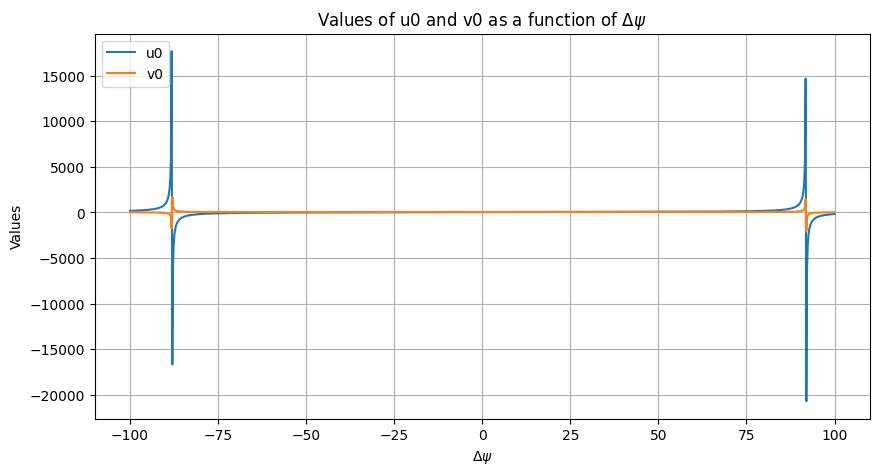

In [32]:
import numpy as np
import matplotlib.pyplot as plt

dpsi_values = np.deg2rad(np.linspace(-100, 100, 1000))

u0_subs = u0.subs({f: 30, xc: 32, yc: 32, u: 43, v: 35})
v0_subs = v0.subs({f: 30, xc: 32, yc: 32, u: 43, v: 35})

u0_subs = u0.subs({f: 30, xc: 32, yc: 32, u: 31, v: 35})
v0_subs = v0.subs({f: 30, xc: 32, yc: 32, u: 31, v: 35})

u0_values = [u0_subs.subs({dpsi: val}).evalf() for val in dpsi_values]
v0_values = [v0_subs.subs({dpsi: val}).evalf() for val in dpsi_values]

u0_values = np.array(u0_values, dtype=float)
v0_values = np.array(v0_values, dtype=float)


print(np.rad2deg(np.atan2(30, 43 - 32)))

# Plot the values
plt.figure(figsize=(10, 5))
# plt.yscale("log")
plt.plot(np.rad2deg(dpsi_values), u0_values, label="u0")
plt.plot(np.rad2deg(dpsi_values), v0_values, label="v0")
plt.xlabel(r"$\Delta\psi$")
plt.ylabel("Values")
plt.title("Values of u0 and v0 as a function of $\Delta\psi$")
plt.legend()
ylim = 500
# plt.ylim(-ylim, ylim)
plt.grid(True)
plt.show()

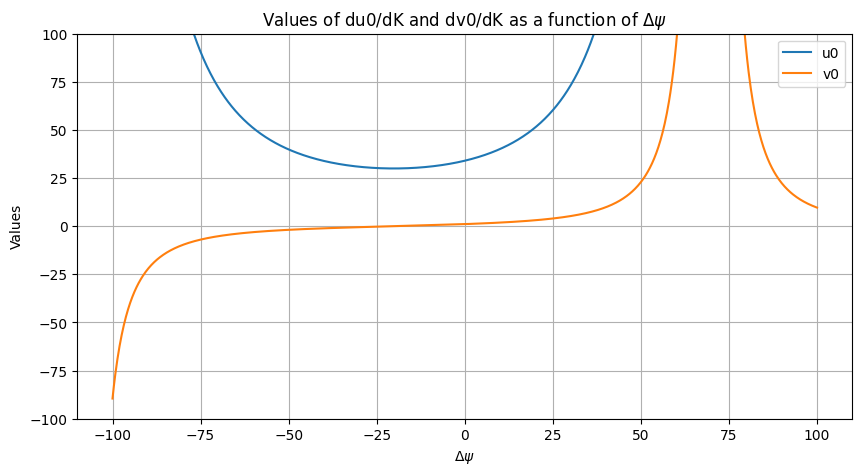

In [33]:
du0_dK_subs = du0_dK.subs({f: 30, xc: 32, yc: 32, u: 43, v: 35})
dv0_dK_subs = dv0_dK.subs({f: 30, xc: 32, yc: 32, u: 43, v: 35})

du0_dK_values = [du0_dK_subs.subs({dpsi: val}).evalf() for val in dpsi_values]
dv0_dK_values = [dv0_dK_subs.subs({dpsi: val}).evalf() for val in dpsi_values]
du0_dK_values = np.array(du0_dK_values, dtype=float)
dv0_dK_values = np.array(dv0_dK_values, dtype=float)

# Plot the values
plt.figure(figsize=(10, 5))
plt.plot(np.rad2deg(dpsi_values), du0_dK_values, label="u0")
plt.plot(np.rad2deg(dpsi_values), dv0_dK_values, label="v0")
plt.xlabel(r"$\Delta\psi$")
plt.ylabel("Values")
plt.title("Values of du0/dK and dv0/dK as a function of $\Delta\psi$")
plt.legend()
plt.grid(True)
plt.ylim(-100, 100)
plt.show()

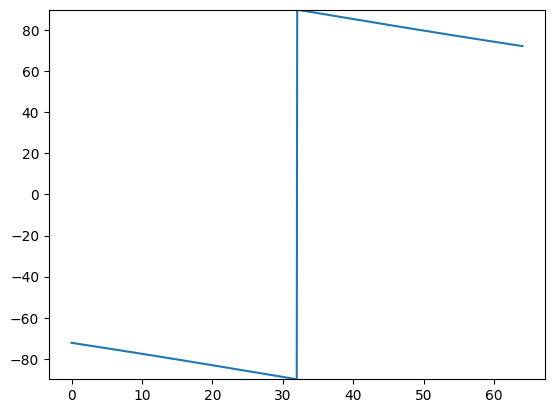

In [34]:
ff = 100
ww = 64
xc = ww // 2
uu = np.linspace(0, ww, 1000)

plt.figure()
plt.plot(uu, np.rad2deg(np.atan(ff / (uu - xc))))
plt.ylim(-90, 90)
plt.show()

### Roll $\phi$

In [35]:
H_phi = H.subs({dx: 0, dy: 0, dz: 0, dtheta: 0, dpsi: 0})
H_phi = sympy.simplify(H_phi)
H_phi_inv = H_phi.inv().simplify()
H_phi_inv

Matrix([
[cos(\Delta\phi), -sin(\Delta\phi), -x_c*cos(\Delta\phi) + x_c + y_c*sin(\Delta\phi)],
[sin(\Delta\phi),  cos(\Delta\phi), -x_c*sin(\Delta\phi) - y_c*cos(\Delta\phi) + y_c],
[              0,                0,                                                1]])

In [36]:
str(H_phi_inv)

'Matrix([[cos(\\Delta\\phi), -sin(\\Delta\\phi), -x_c*cos(\\Delta\\phi) + x_c + y_c*sin(\\Delta\\phi)], [sin(\\Delta\\phi), cos(\\Delta\\phi), -x_c*sin(\\Delta\\phi) - y_c*cos(\\Delta\\phi) + y_c], [0, 0, 1]])'

### Pitch $\theta$

In [37]:
H_theta = H.subs({dx: 0, dy: 0, dz: 0, dphi: 0, dpsi: 0})
H_theta = sympy.simplify(H_theta)
H_theta_inv = H_theta.inv().simplify()
H_theta_inv

Matrix([
[1,                                                                                             x_c*sin(\Delta\theta)/f, x_c*(f*cos(\Delta\theta) - f - y_c*sin(\Delta\theta))/f],
[0, (-f**2*sin(\Delta\theta)**2 + f**2 - y_c**2*sin(\Delta\theta)**2)/(f*(f*cos(\Delta\theta) - y_c*sin(\Delta\theta))),                    (-f**2 - y_c**2)*sin(\Delta\theta)/f],
[0,                                                                                                 sin(\Delta\theta)/f,             cos(\Delta\theta) - y_c*sin(\Delta\theta)/f]])

### $x$-translation

In [38]:
H_x = H.subs({dy: 0, dz: 0, dphi: 0, dtheta: 0, dpsi: 0})
H_x = sympy.simplify(H_x)
H_x_inv = H_x.inv().simplify()
H_x_inv

Matrix([
[(\Delta x*f*sin(theta) + \Delta x*x_c*sin(phi)*cos(theta) - f*z)/(f*(\Delta x*sin(theta) - z)),                                 \Delta x*x_c*cos(phi)*cos(theta)/(f*(\Delta x*sin(theta) - z)), \Delta x*x_c*(f*sin(theta) + x_c*sin(phi)*cos(theta) + y_c*cos(phi)*cos(theta))/(f*(-\Delta x*sin(theta) + z))],
[                                \Delta x*y_c*sin(phi)*cos(theta)/(f*(\Delta x*sin(theta) - z)), (\Delta x*f*sin(theta) + \Delta x*y_c*cos(phi)*cos(theta) - f*z)/(f*(\Delta x*sin(theta) - z)), \Delta x*y_c*(f*sin(theta) + x_c*sin(phi)*cos(theta) + y_c*cos(phi)*cos(theta))/(f*(-\Delta x*sin(theta) + z))],
[                                    \Delta x*sin(phi)*cos(theta)/(f*(\Delta x*sin(theta) - z)),                                     \Delta x*cos(phi)*cos(theta)/(f*(\Delta x*sin(theta) - z)),     (\Delta x*x_c*sin(phi)*cos(theta) + \Delta x*y_c*cos(phi)*cos(theta) + f*z)/(f*(-\Delta x*sin(theta) + z))]])

In [39]:
H_x_inv.subs({phi: 0, theta: 0})

Matrix([
[1,         -\Delta x*x_c/(f*z),     \Delta x*x_c*y_c/(f*z)],
[0, -(\Delta x*y_c - f*z)/(f*z),      \Delta x*y_c**2/(f*z)],
[0,             -\Delta x/(f*z), (\Delta x*y_c + f*z)/(f*z)]])

In [40]:
print(H_x_inv)

Matrix([[(\Delta x*f*sin(theta) + \Delta x*x_c*sin(phi)*cos(theta) - f*z)/(f*(\Delta x*sin(theta) - z)), \Delta x*x_c*cos(phi)*cos(theta)/(f*(\Delta x*sin(theta) - z)), \Delta x*x_c*(f*sin(theta) + x_c*sin(phi)*cos(theta) + y_c*cos(phi)*cos(theta))/(f*(-\Delta x*sin(theta) + z))], [\Delta x*y_c*sin(phi)*cos(theta)/(f*(\Delta x*sin(theta) - z)), (\Delta x*f*sin(theta) + \Delta x*y_c*cos(phi)*cos(theta) - f*z)/(f*(\Delta x*sin(theta) - z)), \Delta x*y_c*(f*sin(theta) + x_c*sin(phi)*cos(theta) + y_c*cos(phi)*cos(theta))/(f*(-\Delta x*sin(theta) + z))], [\Delta x*sin(phi)*cos(theta)/(f*(\Delta x*sin(theta) - z)), \Delta x*cos(phi)*cos(theta)/(f*(\Delta x*sin(theta) - z)), (\Delta x*x_c*sin(phi)*cos(theta) + \Delta x*y_c*cos(phi)*cos(theta) + f*z)/(f*(-\Delta x*sin(theta) + z))]])


### $y$-translation

In [41]:
H_y = H.subs({dx: 0, dz: 0, dphi: 0, dtheta: 0, dpsi: 0})
H_y = sympy.simplify(H_y)
H_y_inv = H_y.inv().simplify()
H_y_inv

Matrix([
[z/(\Delta y*sin(phi)*cos(theta) + z), -\Delta y*cos(phi)*cos(theta)/(\Delta y*sin(phi)*cos(theta) + z), \Delta y*(f*sin(theta) + x_c*sin(phi)*cos(theta) + y_c*cos(phi)*cos(theta))/(\Delta y*sin(phi)*cos(theta) + z)],
[                                   0,                                                                1,                                                                                                              0],
[                                   0,                                                                0,                                                                                                              1]])

In [42]:
H_y_inv.subs({phi: 0, theta: 0})

Matrix([
[1, -\Delta y/z, \Delta y*y_c/z],
[0,           1,              0],
[0,           0,              1]])

### $z$-translation

In [43]:
H_z = H.subs({dx: 0, dy: 0, dphi: 0, dtheta: 0, dpsi: 0})
H_z = sympy.simplify(H_z)
H_z_inv = H_z.inv().simplify()
H_z_inv

Matrix([
[                                                               1,                                    0,                                                                                                              0],
[-\Delta z*sin(phi)*cos(theta)/(\Delta z*cos(phi)*cos(theta) + z), z/(\Delta z*cos(phi)*cos(theta) + z), \Delta z*(f*sin(theta) + x_c*sin(phi)*cos(theta) + y_c*cos(phi)*cos(theta))/(\Delta z*cos(phi)*cos(theta) + z)],
[                                                               0,                                    0,                                                                                                              1]])

In [44]:
H_z_inv.subs({phi: 0, theta: 0})

Matrix([
[1,                0,                           0],
[0, z/(\Delta z + z), \Delta z*y_c/(\Delta z + z)],
[0,                0,                           1]])